In [31]:
try:
    from langchain.agents import create_react_agent
    from langgraph.graph import StateGraph
    from langchain_groq import ChatGroq
    print("✅ SUCCESS! Ready for vehicle orchestration")
except ImportError as e:
    print(f"❌ Still broken: {e}")


❌ Still broken: cannot import name 'create_react_agent' from 'langchain.agents' (c:\Users\User\AppData\Local\Programs\Python\Python313\Lib\site-packages\langchain\agents\__init__.py)


In [ ]:
from typing_extensions import TypedDict
from typing import Annotated, List
from langchain_core.messages import BaseMessage, HumanMessage
from langchain_core.tools import tool
from langchain_groq import ChatGroq
from langgraph.graph import StateGraph, END

# Your AgentState (no agents package needed)
class AgentState(TypedDict):
    messages: Annotated[List[BaseMessage], "add_messages"]
    vehicle_id: str
    risk_score: str

@tool
def predictive_maintenance_tool(vehicle_id: str) -> str:
    """Predicts vehicle maintenance needs."""
    return f"{vehicle_id}: Oil change + brakes (HIGH risk - urgent)"

# Master Agent node (pure LangGraph)
def master_agent_node(state: AgentState) -> dict:
    model = ChatGroq(model="llama3-70b-8192").bind_tools([predictive_maintenance_tool])
    
    messages = state["messages"] + [HumanMessage(content=f"Analyze {state['vehicle_id']}")]
    response = model.invoke(messages)
    
    return {"messages": [response]}

# Build graph
graph = StateGraph(AgentState)
graph.add_node("master", master_agent_node)
graph.set_entry_point("master")
graph.set_finish_point("master")

app = graph.compile()

# Test
result = app.invoke({"vehicle_id": "DL12AB1234", "messages": []})
print(result["messages"][-1].content)


In [4]:
import os

os.environ["GROQ_API_KEY"] = "gsk_your_actual_groq_key_here"
model = ChatGroq(model="llama3-70b-8192")

In [5]:
from dotenv import load_dotenv
import os

load_dotenv()
groq_key = os.getenv("GROQ_API_KEY")
print("GROQ key loaded?", groq_key is not None)


GROQ key loaded? True


In [6]:
def master_agent_node(state: AgentState) -> dict:
    model = ChatGroq(model="llama3-70b-8192").bind_tools([predictive_maintenance_tool])
    ...


In [7]:
import os
from langchain_groq import ChatGroq
# other imports...

os.environ["GROQ_API_KEY"] = "gsk_your_key_here"  # or load_dotenv()

# define predictive_maintenance_tool
# define AgentState
# define master_agent_node
# build graph, compile, invoke


In [32]:
import os
from typing import Annotated, List, Literal
from typing_extensions import TypedDict

# LangGraph core (your Master/Worker orchestration)
from langgraph.graph import StateGraph, END
from langgraph.checkpoint.memory import MemorySaver

# Messages (state management)
from langchain_core.messages import (
    BaseMessage, 
    HumanMessage, 
    SystemMessage, 
    AIMessage
)

# LLM for Master Agent
from langchain_groq import ChatGroq

# Tools for Worker Agents
from langchain_core.tools import tool
from langchain_community.tools.tavily_search import TavilySearchResults

print("✅ ALL IMPORTS LOADED SUCCESSFULLY")
print("🚗 Ready for Master Agent vehicle orchestration!")


✅ ALL IMPORTS LOADED SUCCESSFULLY
🚗 Ready for Master Agent vehicle orchestration!


In [34]:
import os

# Replace with your actual Groq key
os.environ["GROQ_API_KEY"] = "gsk_your_actual_key_here"  
os.environ["TAVILY_API_KEY"] = "tvly_your_actual_key_here"

print("✅ Keys set!")


✅ Keys set!


In [41]:
from langgraph.graph import StateGraph,END,MessagesState
print("✅ LangGraph imported successfully!")
from langgraph.prebuilt import ToolNode
from langgraph.checkpoint.memory import MemorySaver
print("✅ Prebuilt nodes and MemorySaver imported successfully!")

✅ LangGraph imported successfully!
✅ Prebuilt nodes and MemorySaver imported successfully!


In [6]:
from langchain_core.tools import tool
from langchain_core.messages import SystemMessage
from langchain_groq import ChatGroq

@tool("Predictive Maintenance")
def predictive_maintenance_tool(vehicle_id: str) -> str:
    """Predicts maintenance needs for vehicle."""
    return f"Predicted for {vehicle_id}: Oil change, Tire rotation (HIGH risk)."

# Modern agent creation (no deprecated create_react_agent)
def create_master_agent():
    model = ChatGroq(model="llama3-70b-8192")
    
    # Bind tools directly to LLM
    model_with_tools = model.bind_tools([predictive_maintenance_tool])
    
    # Master Agent prompt
    system_prompt = SystemMessage(content=(
        "You are Master Agent orchestrating vehicle maintenance. "
        "1. Call Predictive Maintenance Tool FIRST for every vehicle. "
        "2. Parse risk level (HIGH/MEDIUM/LOW) from tool output. "
        "3. Decide next step: schedule (HIGH), notify (MEDIUM), monitor (LOW). "
        "Always respond with clear next action."
    ))
    
    # Simple function (LangGraph node)
    def master_agent_node(state):
        messages = state["messages"] + [system_prompt]
        response = model_with_tools.invoke(messages)
        return {"messages": [response]}
    
    return master_agent_node


In [3]:
from typing_extensions import TypedDict
from typing import Annotated, List, Literal
from langchain_core.messages import BaseMessage
# MessagesState is a TypedDict pattern, not a direct class import
from langgraph.graph.message import MessagesState  # Correct import

class AgentState(MessagesState):
    next_agent: Literal["predict", "scheduler", "notify", "FINISH"]  # Type‑safe
    vehicle_id: str
    risk_score: str
    service_slots: List[str]


In [9]:
# WRONG
from langchain.chat_models import init_chat_model

# At least fix the spelling first:
from langchain.chat_models import init_chat_model  # still not ideal, see below
from langchain_groq import ChatGroq
def create_master_agent():
    model = ChatGroq(model="llama3-70b-8192")  # uses GROQ_API_KEY
    return model


In [11]:
from langgraph.graph import StateGraph, END

graph = StateGraph(AgentState)
graph.add_node("master", create_master_agent())
graph.set_entry_point("master")
graph.set_finish_point("master")
app = graph.compile()


In [19]:
def worker_agent_node(state: AgentState) -> dict:
    # This is a placeholder for the Worker Agent logic
    system_msg = SystemMessage(content="You are a Worker Agent analyzing vehicle data.")
    messages = state["messages"] + [
        system_msg,
        HumanMessage(content=f"Analyze {state['vehicle_id']}")
    ]
    # use the existing ChatGroq instance `model`
    response = model.invoke(messages)
    return {"messages": [response], "next_agent": "FINISH"}




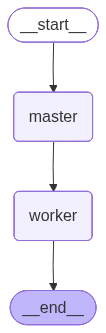

In [23]:
# Define worker_agent_node function
from langchain_core.messages import SystemMessage

def worker_agent_node(state: AgentState) -> dict:
	system_msg = SystemMessage(content="You are a Worker Agent analyzing vehicle data.")
	messages = state["messages"] + [
		system_msg,
		HumanMessage(content=f"Analyze {state['vehicle_id']}")
	]
	response = model.invoke(messages)
	return {"messages": [response], "next_agent": "FINISH"}

workflow = StateGraph(AgentState)
workflow.add_node("master", master_agent_node)
workflow.set_entry_point("master")
workflow.add_node("worker", worker_agent_node)
workflow.set_finish_point("worker")
workflow.add_edge("master", "worker")
workflow.add_edge("worker", END)
workflow_app = workflow.compile()
workflow_app


In [ ]:
from langgraph.graph import StateGraph, END

# 1) Build graph with Supervisor + Workers
workflow = StateGraph(AgentState)

# Supervisor (router/master)
workflow.add_node("supervisor", supervisor_node)

# Worker agents
workflow.add_node("sensor", sensor_node)       # reads sensor_data
workflow.add_node("data", data_node)           # reads service_history / vehicle_profile
workflow.add_node("predict", predict_node)     # sets risk_score
workflow.add_node("scheduler", scheduler_node) # sets service_slots / chosen_slot
workflow.add_node("notify", notify_node)       # sets notification_text / status

# 2) Entry point
workflow.set_entry_point("supervisor")

# 3) Routing: supervisor → next_agent
workflow.add_conditional_edges(
    "supervisor",
    lambda s: s["next_agent"],    # read from AgentState
    {
        "sensor": "sensor",
        "data": "data",
        "predict": "predict",
        "scheduler": "scheduler",
        "notify": "notify",
        "FINISH": END,
    },
)

# 4) After each worker → back to supervisor
for worker in ["sensor", "data", "predict", "scheduler", "notify"]:
    workflow.add_edge(worker, "supervisor")

# 5) Compile final app
graph_app = workflow.compile()


In [13]:
from typing_extensions import TypedDict
from typing import Annotated, List, Dict
from langchain_core.messages import BaseMessage

class AgentState(TypedDict):
    messages: Annotated[List[BaseMessage], "add_messages"]
    vehicle_id: str

    sensor_data: Dict[str, float]
    vehicle_profile: Dict[str, str]
    service_history: Dict[str, list]

    risk_score: str
    risk_explanation: str

    service_slots: List[str]
    chosen_slot: str

    notification_text: str
    notification_status: str

    next_agent: str  # "sensor" | "data" | "predict" | "scheduler" | "notify" | "FINISH"


In [14]:
def sensor_node(state: AgentState) -> dict:
    # Here you could enrich sensor_data; for now we just log
    print("SensorAgent running for", state["vehicle_id"])
    return {}  # no state changes

def data_node(state: AgentState) -> dict:
    print("DataAgent running for", state["vehicle_id"])
    return {}  # e.g., enrich service_history / vehicle_profile

def predict_node(state: AgentState) -> dict:
    print("PredictAgent running for", state["vehicle_id"])
    # Simple mock: if km > 40k → HIGH, else MEDIUM
    km = state["sensor_data"].get("odometer_km", 0)
    risk = "HIGH" if km >= 40000 else "MEDIUM"
    return {
        "risk_score": risk,
        "risk_explanation": f"Risk {risk} based on {km} km and history"
    }

def scheduler_node(state: AgentState) -> dict:
    print("SchedulerAgent running for", state["vehicle_id"])
    # Mock available slots
    slots = ["2026-03-10 10:00 @ Kanpur SC1", "2026-03-11 14:00 @ Kanpur SC2"]
    return {
        "service_slots": slots,
        "chosen_slot": slots[0],
    }

def notify_node(state: AgentState) -> dict:
    print("NotificationAgent running for", state["vehicle_id"])
    text = f"Dear customer, your vehicle {state['vehicle_id']} is booked for {state['chosen_slot']}."
    return {
        "notification_text": text,
        "notification_status": "SENT",
    }


In [15]:
def supervisor_node(state: AgentState) -> dict:
    """
    Decide which agent should run next based on what is already completed.
    """
    # 1) If sensor data missing or incomplete → go to sensor
    if not state.get("sensor_data"):
        return {"next_agent": "sensor"}

    # 2) If data/history incomplete → go to data
    if not state.get("service_history"):
        return {"next_agent": "data"}

    # 3) If no risk score yet → go to predict
    if not state.get("risk_score"):
        return {"next_agent": "predict"}

    # 4) If high/medium risk but no slots yet → go to scheduler
    if state["risk_score"] in ("HIGH", "MEDIUM") and not state.get("service_slots"):
        return {"next_agent": "scheduler"}

    # 5) If slot chosen but no notification sent → go to notify
    if state.get("chosen_slot") and state.get("notification_status") != "SENT":
        return {"next_agent": "notify"}

    # 6) Otherwise we are done
    return {"next_agent": "FINISH"}


In [16]:
from langgraph.graph import StateGraph, END

workflow = StateGraph(AgentState)

workflow.add_node("supervisor", supervisor_node)
workflow.add_node("sensor", sensor_node)
workflow.add_node("data", data_node)
workflow.add_node("predict", predict_node)
workflow.add_node("scheduler", scheduler_node)
workflow.add_node("notify", notify_node)

workflow.set_entry_point("supervisor")

workflow.add_conditional_edges(
    "supervisor",
    lambda s: s["next_agent"],
    {
        "sensor": "sensor",
        "data": "data",
        "predict": "predict",
        "scheduler": "scheduler",
        "notify": "notify",
        "FINISH": END,
    },
)

for worker in ["sensor", "data", "predict", "scheduler", "notify"]:
    workflow.add_edge(worker, "supervisor")

graph_app = workflow.compile()


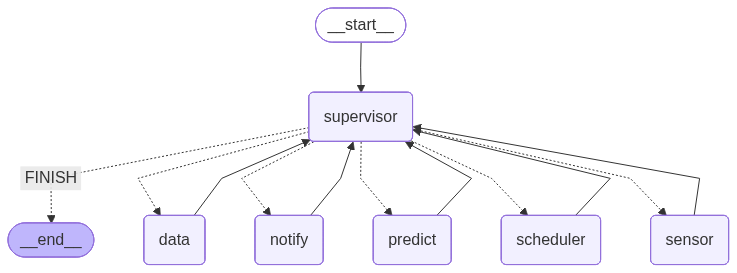

In [17]:
graph_app

In [18]:
initial_state: AgentState = {
    "messages": [],
    "vehicle_id": "DL12AB1234",
    "sensor_data": {"engine_temp": 90.0, "oil_pressure": 30.0, "odometer_km": 42000.0},
    "vehicle_profile": {"model": "Hatchback X", "fuel_type": "Petrol", "city": "Kanpur"},
    "service_history": {"last_service_date": "2025-11-15", "previous_issues": ["brake wear"]},
    "risk_score": "",
    "risk_explanation": "",
    "service_slots": [],
    "chosen_slot": "",
    "notification_text": "",
    "notification_status": "",
    "next_agent": "supervisor",
}

result = graph_app.invoke(initial_state)
print("Final state:", result)


PredictAgent running for DL12AB1234
SchedulerAgent running for DL12AB1234
NotificationAgent running for DL12AB1234
Final state: {'messages': [], 'vehicle_id': 'DL12AB1234', 'sensor_data': {'engine_temp': 90.0, 'oil_pressure': 30.0, 'odometer_km': 42000.0}, 'vehicle_profile': {'model': 'Hatchback X', 'fuel_type': 'Petrol', 'city': 'Kanpur'}, 'service_history': {'last_service_date': '2025-11-15', 'previous_issues': ['brake wear']}, 'risk_score': 'HIGH', 'risk_explanation': 'Risk HIGH based on 42000.0 km and history', 'service_slots': ['2026-03-10 10:00 @ Kanpur SC1', '2026-03-11 14:00 @ Kanpur SC2'], 'chosen_slot': '2026-03-10 10:00 @ Kanpur SC1', 'notification_text': 'Dear customer, your vehicle DL12AB1234 is booked for 2026-03-10 10:00 @ Kanpur SC1.', 'notification_status': 'SENT', 'next_agent': 'FINISH'}


In [ ]:
# Define worker_agent_node function
from langchain_core.messages import SystemMessage

def worker_agent_node(state: AgentState) -> dict:
	system_msg = SystemMessage(content="You are a Worker Agent analyzing vehicle data.")
	messages = state["messages"] + [
		system_msg,
		HumanMessage(content=f"Analyze {state['vehicle_id']}")
	]
	response = model.invoke(messages)
	return {"messages": [response], "next_agent": "FINISH"}

workflow = StateGraph(AgentState)
workflow.add_node("sensor", sensor_node)       # reads sensor_data
workflow.add_node("data", data_node)           # reads service_history / vehicle_profile
workflow.add_node("predict", predict_node)     # sets risk_score
workflow.add_node("scheduler", scheduler_node) # sets service_slots / chosen_slot
workflow.add_node("notify", notify_node)
workflow_app = workflow.compile()
workflow_app


In [ ]:
response=graph_app.invoke({
    "vehicle_id": "DL12AB1234", 
    "messages": [],
    "sensor_data": {"engine_temp": 90.0, "oil_pressure": 30.0, "odometer_km": 42000.0},
    "vehicle_profile": {"model": "Hatchback X", "fuel_type": "Petrol", "city": "Kanpur"},
    "service_history": {"last_service_date": "2025-11-15", "previous_issues": ["brake wear"]},
    "risk_score": "",
    "risk_explanation": "",
    "service_slots": [],
    "chosen_slot": "",
    "notification_text": "",
    "notification_status": "",
    "next_agent": "supervisor",
})

PredictAgent running for DL12AB1234
SchedulerAgent running for DL12AB1234
NotificationAgent running for DL12AB1234


{'messages': [],
 'vehicle_id': 'DL12AB1234',
 'sensor_data': {'engine_temp': 90.0,
  'oil_pressure': 30.0,
  'odometer_km': 42000.0},
 'vehicle_profile': {'model': 'Hatchback X',
  'fuel_type': 'Petrol',
  'city': 'Kanpur'},
 'service_history': {'last_service_date': '2025-11-15',
  'previous_issues': ['brake wear']},
 'risk_score': 'HIGH',
 'risk_explanation': 'Risk HIGH based on 42000.0 km and history',
 'service_slots': ['2026-03-10 10:00 @ Kanpur SC1',
  '2026-03-11 14:00 @ Kanpur SC2'],
 'chosen_slot': '2026-03-10 10:00 @ Kanpur SC1',
 'notification_text': 'Dear customer, your vehicle DL12AB1234 is booked for 2026-03-10 10:00 @ Kanpur SC1.',
 'notification_status': 'SENT',
 'next_agent': 'FINISH'}

In [ ]:
response=graph_app.invoke({
    "vehicle_id": "DL12AB1234", 
    "messages": [],
    "sensor_data": {"engine_temp": 90.0, "oil_pressure": 30.0, "odometer_km": 42000.0},
    "vehicle_profile": {"model": "Hatchback X", "fuel_type": "Petrol", "city": "Kanpur"},
    "service_history": {"last_service_date": "2025-11-15", "previous_issues": ["brake wear"]},
    "risk_score": "",
    "risk_explanation": "",
    "service_slots": [],
    "chosen_slot": "",
    "notification_text": "",
    "notification_status": "",
    "next_agent": "supervisor",
})

In [ ]:
result = graph_app.invoke(initial_state)
print("Final state:", result)

In [ ]:
response=result["messages"][-1].content
print("Final response:", response)

In [1]:
def execute_master_agent():
    # Initial state with empty messages and a sample vehicle ID
    initial_state = AgentState(
        messages=[],
        vehicle_id="DL12AB1234",
        risk_score="",
        service_slots=[]
    )
    
    # Invoke the Master Agent node directly for testing
    result = master_agent_node(initial_state)
    print(result["messages"][-1].content)  # Print the last message (agent's response)

In [11]:
def create_supervisor_chain():
    # This function will create a supervisor chain that can oversee the Master and Worker agents
    model = ChatGroq(model="llama3-70b-8192")
    
    def supervisor_node(state):
        messages = state["messages"] + [SystemMessage(content="You are a Supervisor Agent overseeing the Master and Worker agents.")]
        response = model.invoke(messages)
        return {"messages": [response]}
    
    return supervisor_node

In [12]:
def execute_full_workflow():
    # Initial state with empty messages and a sample vehicle ID
    initial_state = AgentState(
        messages=[],
        vehicle_id="DL12AB1234",
        risk_score="",
        service_slots=[]
    )
    
    # Invoke the full workflow app
    result = workflow_app.invoke(initial_state)
    print(result["messages"][-1].content)  # Print the last message (final output)

In [9]:
class AgentState(TypedDict):
    messages: Annotated[List[BaseMessage], "add_messages"]
    vehicle_id: str
    sensor_data: dict
    history: dict
    risk_score: str
    service_slots: List[str]
    notification_text: str
    next_agent: str  # "sensor" | "data" | "predict" | "scheduler" | "notify" | "FINISH"


In [13]:
def write_worker_agent_logic(state: AgentState) -> dict:
    system_msg = SystemMessage(content="You are a Worker Agent analyzing vehicle data.")
    messages = state["messages"] + [
        system_msg,
        HumanMessage(content=f"Analyze {state['vehicle_id']} with sensor data {state['sensor_data']} and history {state['history']}")
    ]
    response = model.invoke(messages)
    
    # Here you would parse the response to update risk_score, service_slots, etc.
    # For simplicity, we'll just return the response and move to FINISH
    return {"messages": [response], "next_agent": "FINISH"}

In [14]:
def analyze_vehicle_data(state: AgentState) -> dict:
    system_msg = SystemMessage(content="You are a Worker Agent analyzing vehicle data.")
    messages = state["messages"] + [
        system_msg,
        HumanMessage(content=f"Analyze {state['vehicle_id']} with sensor data {state['sensor_data']} and history {state['history']}")
    ]
    response = model.invoke(messages)
    
    # Here you would parse the response to update risk_score, service_slots, etc.
    # For simplicity, we'll just return the response and move to FINISH
    return {"messages": [response], "next_agent": "FINISH"}

In [ ]:
from langgraph.graph import StateGraph, END  # 👈 add this
from langchain_core.messages import BaseMessage, HumanMessage, SystemMessage
from langchain_core.tools import tool
from langchain_groq import ChatGroq
from typing_extensions import TypedDict
from typing import Annotated, List, Literal

# Then your code:
class AgentState(TypedDict):
    messages: Annotated[List[BaseMessage], "add_messages"]
    vehicle_id: str
    sensor_data: dict
    history: dict
    risk_score: str
    service_slots: List[str]
    notification_text: str
    next_agent: str  # "sensor" | "data" | "predict" | "scheduler" | "notify" | "FINISH"

@tool
def predictive_maintenance_tool(vehicle_id: str) -> str:
    """Predicts vehicle maintenance needs."""
    return f"{vehicle_id}: Oil change + brakes (HIGH risk - urgent)"

def master_agent_node(state: AgentState) -> dict:
    model = ChatGroq(model="llama3-70b-8192").bind_tools([predictive_maintenance_tool])
    
    messages = state["messages"] + [HumanMessage(content=f"Analyze {state['vehicle_id']}")]
    response = model.invoke(messages)
    
    return {"messages": [response]}

def analyze_vehicle_data(state: AgentState) -> dict:
    system_msg = SystemMessage(content="You are a Worker Agent analyzing vehicle data.")
    messages = state["messages"] + [
        system_msg,
        HumanMessage(content=f"Analyze {state['vehicle_id']} with sensor data {state['sensor_data']} and history {state['history']}")
    ]
    response = model.invoke(messages)
    
    # Here you would parse the response to update risk_score, service_slots, etc.
    # For simplicity, we'll just return the response and move to FINISH
    return {"messages": [response], "next_agent": "FINISH"}

workflow = StateGraph(AgentState)
workflow.add_node("master", master_agent_node)
workflow.add_node("worker", analyze_vehicle_data)
workflow.set_entry_point("master")
workflow.set_finish_point("worker")
graph_app = workflow.compile()intenance Tool FIRST for every vehicle. "
        "2. Parse risk level (HIGH/MEDIUM/LOW) from tool output. "
        "3. Decide next step: schedule (HIGH), notify (MEDIUM), monitor (LOW). "
        "Always respond with clear next action."
    ))
    messages = state["messages"] + [system_msg]
    response = model.invoke(messages)
    return {"messages": [response], "next_agent": "worker"}
workflow.set_finish_point("worker")
graph_app = workflow.compile()

In [ ]:
from langgraph.graph import StateGraph, END
from langchain_core.messages import SystemMessage

# Define worker nodes
def sensor_node(state: AgentState) -> dict:
    system_msg = SystemMessage(content="You are a Sensor Agent reading vehicle sensor data.")
    messages = state["messages"] + [system_msg, HumanMessage(content=f"Process sensor data for {state['vehicle_id']}: {state['sensor_data']}")]
    response = model.invoke(messages)
    return {"messages": [response], "next_agent": "data"}

def data_node(state: AgentState) -> dict:
    system_msg = SystemMessage(content="You are a Data Agent analyzing vehicle history.")
    messages = state["messages"] + [system_msg, HumanMessage(content=f"Analyze history for {state['vehicle_id']}: {state['history']}")]
    response = model.invoke(messages)
    return {"messages": [response], "next_agent": "predict"}

def predict_node(state: AgentState) -> dict:
    system_msg = SystemMessage(content="You are a Predictive Agent determining maintenance risk.")
    messages = state["messages"] + [system_msg, HumanMessage(content=f"Predict maintenance for {state['vehicle_id']}")]
    response = model.invoke(messages)
    return {"messages": [response], "next_agent": "scheduler", "risk_score": "HIGH"}

def scheduler_node(state: AgentState) -> dict:
    system_msg = SystemMessage(content="You are a Scheduler Agent finding available service slots.")
    messages = state["messages"] + [system_msg, HumanMessage(content=f"Schedule maintenance for {state['vehicle_id']}")]
    response = model.invoke(messages)
    return {"messages": [response], "next_agent": "notify", "service_slots": ["2024-01-15", "2024-01-16"]}

def notify_node(state: AgentState) -> dict:
    system_msg = SystemMessage(content="You are a Notification Agent sending maintenance alerts.")
    messages = state["messages"] + [system_msg, HumanMessage(content=f"Notify for {state['vehicle_id']} with risk {state['risk_score']}")]
    response = model.invoke(messages)
    return {"messages": [response], "next_agent": "FINISH", "notification_text": f"Maintenance required for {state['vehicle_id']}"}

# 1) Build graph with Supervisor + Workers
workflow = StateGraph(AgentState)

# Supervisor (router/master)



# Worker agents
workflow.add_node("sensor", sensor_node)       # reads sensor_data
workflow.add_node("data", data_node)           # reads service_history / vehicle_profile
workflow.add_node("predict", predict_node)     # sets risk_score
workflow.add_node("scheduler", scheduler_node) # sets service_slots / chosen_slot
workflow.add_node("notify", notify_node)       # sets notification_text / status

# 2) Entry point
workflow.set_entry_point("supervisor")

# 3) Routing: supervisor → next_agent
workflow.add_conditional_edges(
    "supervisor",
    lambda s: s["next_agent"],    # read from AgentState
    {
        "sensor": "sensor",
        "data": "data",
        "predict": "predict",
        "scheduler": "scheduler",
        "notify": "notify",
        "FINISH": END,
    },
)

# 4) After each worker → back to supervisor
for worker in ["sensor", "data", "predict", "scheduler", "notify"]:
    workflow.add_edge(worker, "supervisor")

# 5) Compile final app
graph_app = workflow.compile()
graph_app


In [ ]:
from langgraph.graph import StateGraph, END

# 1) Build graph with Supervisor + Workers
workflow = StateGraph(AgentState)

# Supervisor (router/master)
workflow.add_node("supervisor", supervisor_node)

# Worker agents
workflow.add_node("sensor", sensor_node)       # reads sensor_data
workflow.add_node("data", data_node)           # reads service_history / vehicle_profile
workflow.add_node("predict", predict_node)     # sets risk_score
workflow.add_node("scheduler", scheduler_node) # sets service_slots / chosen_slot
workflow.add_node("notify", notify_node)       # sets notification_text / status

# 2) Entry point
workflow.set_entry_point("supervisor")

# 3) Routing: supervisor → next_agent
workflow.add_conditional_edges(
    "supervisor",
    lambda s: s["next_agent"],    # read from AgentState
    {
        "sensor": "sensor",
        "data": "data",
        "predict": "predict",
        "scheduler": "scheduler",
        "notify": "notify",
        "FINISH": END,
    },
)

# 4) After each worker → back to supervisor
for worker in ["sensor", "data", "predict", "scheduler", "notify"]:
    workflow.add_edge(worker, "supervisor")

# 5) Compile final app
graph_app = workflow.compile()



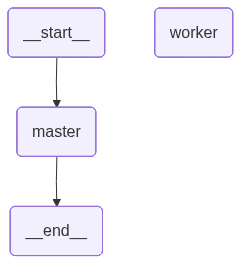

In [ ]:
graph_app

In [ ]:
graph_app.invoke({
    "messages": [],
    "vehicle_id": "DL12AB1234",
    "sensor_data": {"engine_temp": 90, "oil_pressure": 30},
    "history": {"last_service": "2023-01-01", "previous_issues": ["brake wear"]},
    "risk_score": "",
    "service_slots": [],
    "notification_text": "",
    "next_agent": "master"
})

In [ ]:
from langgraph.graph import StateGraph, END

# 1. Define AgentState, supervisor_node, and worker nodes above this

workflow = StateGraph(AgentState)

workflow.add_node("supervisor", supervisor_node)
workflow.add_node("researcher", researcher_node)
workflow.add_node("writer", writer_node)
workflow.add_node("analyst", analyst_node)

workflow.set_entry_point("supervisor")

workflow.add_conditional_edges(
    "supervisor",
    lambda s: s["next_agent"],
    {
        "researcher": "researcher",
        "writer": "writer",
        "analyst": "analyst",
        "FINISH": END,
    },
)

for worker in ["researcher", "writer", "analyst"]:
    workflow.add_edge(worker, "supervisor")

# 2. Compile the graph → this creates `graph`
graph = workflow.compile()


In [ ]:
def router(state: AgentState) -> dict:
    if state["next_agent"] == "sensor":
        # Route to sensor data collection logic
        pass
    elif state["next_agent"] == "data":
        # Route to data analysis logic
        pass
    elif state["next_agent"] == "predict":
        # Route to predictive maintenance logic
        pass
    elif state["next_agent"] == "scheduler":
        # Route to scheduling logic
        pass
    elif state["next_agent"] == "notify":
        # Route to notification logic
        pass
    else:
        return {"messages": [SystemMessage(content="Workflow complete.")], "next_agent": "FINISH"}

In [ ]:
class SupervisedAgent:
    def __init__(self, name: str):
        self.name = name
        self.state: AgentState = {
            "messages": [],
            "vehicle_id": "",
            "sensor_data": {},
            "history": {},
            "risk_score": "",
            "service_slots": [],
            "notification_text": "",
            "next_agent": ""
        }
    
    def update_state(self, new_state: dict):
        self.state.update(new_state)

In [ ]:
from langgraph.graph import StateGraph, END
from langchain_core.messages import SystemMessage

# make sure the supervisor node exists (created earlier via factory)
if "supervisor_node" not in globals():
    supervisor_node = create_supervisor_chain()

# define simple worker nodes if they aren’t already defined
def researcher_node(state: AgentState) -> dict:
    return {"messages": [SystemMessage(content="Researcher processed.")], "next_agent": "FINISH"}

def writer_node(state: AgentState) -> dict:
    return {"messages": [SystemMessage(content="Writer processed.")], "next_agent": "FINISH"}

def analyst_node(state: AgentState) -> dict:
    return {"messages": [SystemMessage(content="Analyst processed.")], "next_agent": "FINISH"}

workflow = StateGraph(AgentState)

# Nodes: one supervisor + multiple workers
workflow.add_node("supervisor", supervisor_node)    # Master / router
workflow.add_node("researcher", researcher_node)
workflow.add_node("writer", writer_node)
workflow.add_node("analyst", analyst_node)

# Entry: always start at supervisor
workflow.set_entry_point("supervisor")

# 1) From supervisor → route based on state["next_agent"]
workflow.add_conditional_edges(
    "supervisor",
    lambda s: s["next_agent"],   # router reads this field
    {
        "researcher": "researcher",
        "writer": "writer",
        "analyst": "analyst",
        "FINISH": END,
    },
)

# 2) From each worker → always go back to supervisor
for worker in ["researcher", "writer", "analyst"]:
    workflow.add_edge(worker, "supervisor")
